# **Netflix Recommendation Engine**

**What are Recommender Systems?**

Recommender systems are algorithms designed to suggest relevant items to users. These systems are used in various domains such as e-commerce, streaming services, and social media. They enhance user experience by filtering vast amounts of information to deliver personalized content.

#SVD (Singular Value Decomposition) in a recommendation system works by finding patterns in user preferences and item similarities.

Here's a basic idea without going deep into the topic

**1) What the System Has: A big table (matrix) with users on one side and items (like movies) on the other. Users give ratings to items, but not everyone has rated everything**

**2) What SVD Does: SVD looks at the ratings that are available and tries to figure out the hidden connections between users and items. It learns what kind of movies users like based on their previous ratings**

**3) How It Helps: Once SVD understands these patterns, it can predict how a user might rate a movie they haven’t seen yet. Based on these predictions, the system recommends movies that the user is most likely to enjoy**

# How Does SVD Work?

**Imagine you have a big dataset in the form of a matrix. The goal of SVD is to represent this matrix as the product of three simpler matrices:**

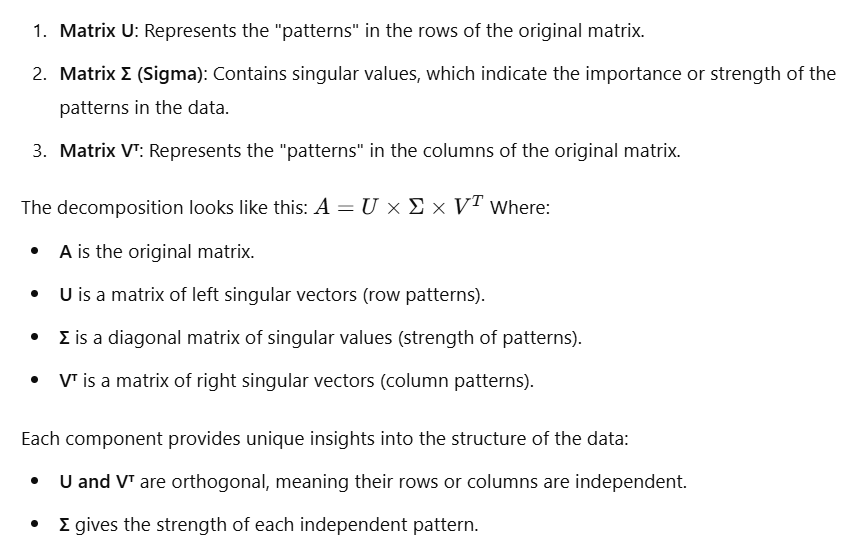

# Step-by-Step Intuition

Let’s use an example of movie ratings to break it down:

Input Matrix: Imagine you have a matrix of users and their ratings for movies. Each cell represents how much a user liked a movie.

**Decomposition:**

U: Groups users into patterns based on their rating preferences (e.g., users who like action movies).

Σ: Identifies how strong or dominant each pattern is (e.g., how many users follow a particular preference).

Vᵀ: Groups movies into patterns based on the ratings they received (e.g., movies in the action genre are liked by similar users).

**Reconstruction:**

 By multiplying U, Σ, and Vᵀ, you can recreate the original matrix. However, you can also keep only the top patterns (largest singular values in Σ) to reduce noise and focus on the most important information.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive

In [ ]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
netflix_dataset = pd.read_csv("/content/drive/MyDrive/Netflix Dataset/combined_data_1.txt.zip",header=None,names=["CustID","Rating"],usecols=[0,1])

In [ ]:
netflix_dataset

,CustID,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [ ]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24058263 entries, 0 to 24058262
Data columns (total 2 columns):
 #   Column  Dtype  
---  ------  -----  
 0   CustID  object 
 1   Rating  float64
dtypes: float64(1), object(1)
memory usage: 367.1+ MB


In [ ]:
netflix_dataset.isnull().sum()

,0
CustID,0
Rating,4499


In [ ]:
#if rating is NAN => VALUE OF CUST_ID => Movie ID

In [ ]:
#movie count?
movie_count = netflix_dataset.isnull().sum()
movie_count = movie_count["Rating"]
movie_count

4499

In [ ]:
#Customer count...
customer_count = netflix_dataset['CustID'].nunique()
customer_count

475257

In [ ]:
customer_count = customer_count - movie_count
customer_count

470758

In [ ]:
movie_id = None
movie_np = []
for cust_id in netflix_dataset['CustID']:
  if ":" in cust_id:
    movie_id = int(cust_id.replace(":",""))
  movie_np.append(movie_id)

In [ ]:
movie_np

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [ ]:
netflix_dataset["Movie_ID"] = movie_np

In [ ]:
netflix_dataset

,CustID,Rating,Movie_ID
0,1:,NaN,1
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [ ]:
netflix_dataset.dropna(inplace=True)

In [ ]:
netflix_dataset

,CustID,Rating,Movie_ID
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [ ]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   CustID    object 
 1   Rating    float64
 2   Movie_ID  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 734.1+ MB


In [ ]:
netflix_dataset['CustID'] = netflix_dataset['CustID'].astype(int)

In [ ]:
#dataset_summary => groupby on movie id based on rating count
data_Summary = netflix_dataset.groupby("Movie_ID")["Rating"].agg(["count"])
data_Summary

,count
Movie_ID,
1,547
2,145
3,2012
4,142
5,1140
...,...
4495,614
4496,9519
4497,714


In [ ]:
movie_benchmark = round(data_Summary['count'].quantile(0.50),0)

In [ ]:
movie_benchmark

552.0

In [ ]:
drop_list = data_Summary[data_Summary['count']<movie_benchmark].index

In [ ]:
drop_list

Index([   1,    2,    4,    7,    9,   10,   11,   12,   13,   14,
       ...
       4475, 4477, 4480, 4481, 4486, 4487, 4491, 4494, 4498, 4499],
      dtype='int64', name='Movie_ID', length=2249)

In [ ]:
cust_summary = netflix_dataset.groupby("CustID")["Rating"].agg(["count"])
cust_summary

,count
CustID,
6,153
7,195
8,21
10,49
25,4
...,...
2649404,12
2649409,10
2649421,3


In [ ]:
cust_benchmark = round(cust_summary['count'].quantile(0.50),0)

In [ ]:
cust_benchmark

24.0

In [ ]:
drop_cust_list = cust_summary[cust_summary['count']<cust_benchmark].index

In [ ]:
drop_cust_list

Index([      8,      25,      33,      83,     126,     130,     133,     142,
           149,     158,
       ...
       2649260, 2649268, 2649326, 2649337, 2649343, 2649379, 2649384, 2649404,
       2649409, 2649421],
      dtype='int64', name='CustID', length=232415)

In [ ]:
netflix_dataset = netflix_dataset[~netflix_dataset['Movie_ID'].isin(drop_list)]
netflix_dataset = netflix_dataset[~netflix_dataset['CustID'].isin(drop_cust_list)]

In [ ]:
netflix_dataset

,CustID,Rating,Movie_ID
695,1025579,4.0,3
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
...,...,...,...
24057558,892598,2.0,4497
24057559,2111672,3.0,4497
24057560,900899,3.0,4497
24057561,1300759,3.0,4497


#Model Building

In [ ]:
movie_titles = pd.read_csv("/content/drive/MyDrive/Netflix Dataset/Copy of movie_titles.csv",encoding="ISO-8859-1",header=None,names=["MovieID","Year","Name"],usecols=[0,1,2])

In [ ]:
movie_titles

,MovieID,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [ ]:
print(np.__version__)

1.26.4


In [ ]:
!pip install numpy==1.26.4

In [ ]:
!pip install scikit-surprise==1.1.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 10.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554969 sha256=aab311f6b078fc488d84d9358e1ac86c9ffd8e299e006db210bff678e5720dc1
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [ ]:
import surprise

In [ ]:
print(surprise.__version__)

1.1.4


In [ ]:
from surprise import Reader,Dataset,SVD

In [ ]:
model = SVD()

In [ ]:
reader = Reader()

In [ ]:
netflix_dataset.shape

(21382104, 3)

In [ ]:
data = Dataset.load_from_df(netflix_dataset[["CustID","Movie_ID","Rating"]][:1000000],reader)

In [ ]:
data

In [ ]:
from surprise.model_selection import cross_validate

In [ ]:
cross_validate(model,data,measures=["RMSE"],cv=3)

{'test_rmse': array([0.97902392, 0.97741433, 0.97774697]),
 'fit_time': (15.314407110214233, 16.284459829330444, 16.380924701690674),
 'test_time': (3.7224605083465576, 2.883829355239868, 5.100623369216919)}

#Recomendation

In [ ]:
netflix_dataset

,CustID,Rating,Movie_ID
695,1025579,4.0,3
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
...,...,...,...
24057558,892598,2.0,4497
24057559,2111672,3.0,4497
24057560,900899,3.0,4497
24057561,1300759,3.0,4497


In [ ]:
movie_titles

,MovieID,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [ ]:
#individual user
user_rating = netflix_dataset[netflix_dataset['CustID']==1331154]
user_rating

,CustID,Rating,Movie_ID
697,1331154,4.0,3
5178,1331154,4.0,8
31460,1331154,3.0,18
92840,1331154,4.0,30
224761,1331154,3.0,44
...,...,...,...
23439584,1331154,4.0,4389
23546489,1331154,2.0,4402
23649431,1331154,4.0,4432
23844441,1331154,3.0,4472


In [ ]:
movie_rated_by_user = user_rating['Movie_ID'].nunique()

In [ ]:
movie_rated_by_user

253

In [ ]:
user_1331154 = movie_titles.copy()
user_1331154

,MovieID,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [ ]:
user_1331154 = user_1331154[~user_1331154['MovieID'].isin(drop_list)]

In [ ]:
user_1331154

,MovieID,Year,Name
2,3,1997.0,Character
4,5,2004.0,The Rise and Fall of ECW
5,6,1997.0,Sick
7,8,2004.0,What the #$*! Do We Know!?
15,16,1996.0,Screamers
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [ ]:
user_1331154["Estimated_Rating"] = user_1331154['MovieID'].apply(lambda x: model.predict(1331154,x).est)

/tmp/ipykernel_6489/1433287501.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_1331154["Estimated_Rating"] = user_1331154['MovieID'].apply(lambda x: model.predict(1331154,x).est)


In [ ]:
prediction = []
for i in user_1331154['MovieID']:
  predict = model.predict(1331153,i).est
  prediction.append(predict)

In [ ]:
prediction

[3.703638702315779,
 4.002333873591347,
 3.1380791573992934,
 3.1953280011824376,
 3.195939190966463,
 3.0309274132562676,
 3.9153782697269044,
 3.61043918280536,
 3.0656509719001064,
 4.050065292330986,
 2.759264828730189,
 3.8252274907605233,
 3.8059245384431506,
 4.075991797712145,
 4.1838760892979945,
 3.152409420440809,
 3.171301809994027,
 2.1043026111977277,
 2.461124788362306,
 3.7346810521943263,
 3.0330044314633193,
 3.8862799502671734,
 3.3445835861156947,
 3.8067034888519657,
 3.8404026957729624,
 3.1048101967217447,
 3.682283296139006,
 3.736317729762301,
 3.729947430119587,
 4.191365867993957,
 3.8948472818581443,
 3.885965354098716,
 4.182517450356191,
 2.939234902037317,
 3.0265706996707338,
 3.8056282334172935,
 3.515604169075941,
 3.8059683661561827,
 3.2500348846363085,
 3.9114661433081452,
 2.7713403063003765,
 3.5377316006992974,
 3.810894615497683,
 2.6595478013029408,
 3.9293368917307268,
 3.795763877080703,
 4.131586453360933,
 3.420038218752812,
 3.100127848893

In [ ]:
user_1331154["Predicted_Rating"] = prediction

/tmp/ipykernel_6489/13960344.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_1331154["Predicted_Rating"] = prediction


In [ ]:
user_1331154

,MovieID,Year,Name,Estimated_Rating,Predicted_Rating
2,3,1997.0,Character,3.572655,3.703639
4,5,2004.0,The Rise and Fall of ECW,4.341192,4.002334
5,6,1997.0,Sick,3.188957,3.138079
7,8,2004.0,What the #$*! Do We Know!?,3.808292,3.195328
15,16,1996.0,Screamers,2.847781,3.195939
...,...,...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...,3.744995,3.645373
17766,17767,2004.0,Fidel Castro: American Experience,3.744995,3.645373
17767,17768,2000.0,Epoch,3.744995,3.645373
17768,17769,2003.0,The Company,3.744995,3.645373


In [ ]:
user_1331154.drop("Predicted_Rating",axis=1,inplace=True)

In [ ]:
user_1331154 = user_1331154.sort_values("Estimated_Rating",ascending=False)

In [ ]:
user_1331154.head(10)

,MovieID,Year,Name,Estimated_Rating
164,165,1982.0,Richard Pryor: Live on the Sunset Strip,4.574028
205,206,2004.0,Unconstitutional: The War on Our Civil Liberties,4.525332
222,223,2003.0,Chappelle's Show: Season 1,4.518476
214,215,1998.0,That '70s Show: Season 1,4.428935
174,175,1992.0,Reservoir Dogs,4.360351
4,5,2004.0,The Rise and Fall of ECW,4.341192
142,143,1997.0,The Game,4.321405
105,106,2004.0,Stevie Ray Vaughan and Double Trouble: Live at...,4.282482
47,48,2001.0,Justice League,4.256582
240,241,1959.0,North by Northwest,4.219104


In [ ]:
user_900899 = movie_titles.copy()

In [ ]:
user_900899 = user_900899[~user_900899['MovieID'].isin(drop_list)]

In [ ]:
user_900899

,MovieID,Year,Name
2,3,1997.0,Character
4,5,2004.0,The Rise and Fall of ECW
5,6,1997.0,Sick
7,8,2004.0,What the #$*! Do We Know!?
15,16,1996.0,Screamers
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [ ]:
user_900899["Estimated_Rating"] = user_900899['MovieID'].apply(lambda x: model.predict(900899,x).est)

In [ ]:
user_900899

,MovieID,Year,Name,Estimated_Rating
2,3,1997.0,Character,3.305269
4,5,2004.0,The Rise and Fall of ECW,4.088590
5,6,1997.0,Sick,2.884731
7,8,2004.0,What the #$*! Do We Know!?,4.267464
15,16,1996.0,Screamers,3.227170
...,...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...,3.652844
17766,17767,2004.0,Fidel Castro: American Experience,3.652844
17767,17768,2000.0,Epoch,3.652844
17768,17769,2003.0,The Company,3.652844


In [ ]:
user_900899.sort_values("Estimated_Rating",ascending=False).head(10)

,MovieID,Year,Name,Estimated_Rating
247,248,2001.0,Michael Moore's The Awful Truth: Season 2,5.000000
75,76,1952.0,I Love Lucy: Season 2,4.641575
32,33,2000.0,Aqua Teen Hunger Force: Vol. 1,4.598133
45,46,1964.0,Rudolph the Red-Nosed Reindeer,4.432961
24,25,1997.0,Inspector Morse 31: Death Is Now My Neighbour,4.421674
166,167,2004.0,The Chorus,4.356559
222,223,2003.0,Chappelle's Show: Season 1,4.308367
250,251,2000.0,Midsomer Murders: Strangler's Wood,4.288286
7,8,2004.0,What the #$*! Do We Know!?,4.267464
223,224,1999.0,Midsomer Murders: Blood Will Out,4.224397
